# GIS presentation, SDG AI Lab

Update: I made a copy of the initial notebook and re ran it so may be different, I also fixed some initial errors and added some extra notes/plans. 
 

## Objective
### Three parts:
#### geographical data management and applied data science and network analysis 

## 1. Geographical data manipulation and management 

### 1.1 load packages

In [2]:
%matplotlib inline
import os
import sys
from glob import glob
import subprocess

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

import seaborn as sns

import geopandas as gpd
import pycrs
import fiona
from fiona.crs import from_epsg
from shapely.geometry import box
from shapely.geometry import Point
import shapely.geometry as geoms

import rasterio as rio
from rasterio.plot import show
import rasterio.warp
import rasterio.shutil
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import plotting_extent
from rasterio.plot import show_hist
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio import Affine, MemoryFile
from rasterio.enums import Resampling
from rasterio import plot

import rasterstats as rs
#from rastertodataframe import raster_to_dataframe

import earthpy.spatial as es
import earthpy.plot as ep
import earthpy as et


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### 1.3 Defining functions

In [11]:
 #define functions:
#load image data 

def process_sentinel_data(path):
    path = os.path.abspath(path)
    os.chdir(path)
    rasters=glob("IMG_DATA/R20m/*B0[2:3:4:8:11]_10m*.jp2")
    raster_arrays = []
    for raster in rasters:
        with rasterio.open(raster, 'r') as src:
            raster_array = src.read()
        raster_arrays.append(raster_array)
        return rasters
   
rasters1 = process_sentinel_data('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Sentinel_Footprints/S2A_MSIL2A_20210910T120321_N0301_R023_T28RBS_20210910T144004.SAFE/GRANULE/L2A_T28RBS_A032481_20210910T120324/')
rasters2 = process_sentinel_data('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Sentinel_Footprints/S2A_MSIL2A_20210930T120331_N0301_R023_T28RBS_20210930T142131.SAFE/GRANULE/L2A_T28RBS_A032767_20210930T120327/')
print (rasters1)
print(rasters2)



None
None


In [ ]:
## stacking files ar resolution 10, bands, 2, 3, 4 and 8

In [ ]:
def stack_dirs(dirs, output_files):
    for i, dir in enumerate(dirs):
        rasters = glob(dir + '/IMG_DATA/R10m/*B0[2:3:4:8:11]_10m*.jp2')
        stack, meta = es.stack(rasters, output_files[i])

dirs = [
    '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Sentinel_Footprints/S2A_MSIL2A_20210910T120321_N0301_R023_T28RBS_20210910T144004.SAFE/GRANULE/L2A_T28RBS_A032481_20210910T120324',
    '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Sentinel_Footprints/S2A_MSIL2A_20210930T120331_N0301_R023_T28RBS_20210930T142131.SAFE/GRANULE/L2A_T28RBS_A032767_20210930T120327'
]
output_files = [
    '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_10_09.jp2',
    '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_30_09.jp2'
]
stack_dirs(dirs, output_files)

In [ ]:
# 2. open raster file, check for meta data
# Open the raster file
with rasterio.open('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_10_09.jp2') as src:
    raster = src.read() 
    meta=src.meta
    print(meta)
    
with rasterio.open('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_30_09.jp2') as src:
    raster2 = src.read() 
    meta2=src.meta
    print(meta2)

### 1.3 resample

In [4]:
#resample to other pixel resolution:
fp = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_10_09.jp2'
fp2 = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/stacked_30_09.jp2'
#uses UTM zone 28N projection


In [ ]:
out = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/resampled_10_09.jp2'
out2 = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/resampled_30_09.jp2'

In [ ]:
#resample to 20m pixel resolution for 10.09

with rasterio.open(fp) as in_ds:
    # Get the input data and metadata
    in_data = in_ds.read()
    in_transform = in_ds.transform
    in_crs = in_ds.crs
    in_width = in_ds.width
    in_height = in_ds.height

# Set the output resolution
out_resolution = 20

# Calculate the output transform and dimensions
out_transform, out_width, out_height = calculate_default_transform(in_crs, in_crs, in_width, in_height, *in_ds.bounds, resolution=out_resolution)

# Create an empty output dataset
out_data = np.empty((in_data.shape[0], out_height, out_width))

# Resample the input data to the output dataset
rasterio.warp.reproject(in_data, out_data, src_transform=in_transform, src_crs=in_crs, dst_transform=out_transform, dst_crs=in_crs, resampling=Resampling.nearest)

# Write the output data to a file, 20 m resolution for 30.09
with rasterio.open(out, 'w', driver='JP2OpenJPEG', width=out_width, height=out_height, count=in_ds.count, dtype=in_ds.dtypes[0], crs=in_crs, transform=out_transform) as out_ds:
    out_ds.write(out_data)
    

with rasterio.open(fp2) as in_ds:
    # Get the input data and metadata
    in_data = in_ds.read()
    in_transform = in_ds.transform
    in_crs = in_ds.crs
    in_width = in_ds.width
    in_height = in_ds.height

# Set the output resolution
out_resolution = 20

# Calculate the output transform and dimensions
out_transform, out_width, out_height = calculate_default_transform(in_crs, in_crs, in_width, in_height, *in_ds.bounds, resolution=out_resolution)

# Create an empty output dataset
out_data = np.empty((in_data.shape[0], out_height, out_width))

# Resample the input data to the output dataset
rasterio.warp.reproject(in_data, out_data, src_transform=in_transform, src_crs=in_crs, dst_transform=out_transform, dst_crs=in_crs, resampling=Resampling.nearest)

# Write the output data to a file
with rasterio.open(out2, 'w', driver='JP2OpenJPEG', width=out_width, height=out_height, count=in_ds.count, dtype=in_ds.dtypes[0], crs=in_crs, transform=out_transform) as out_ds:
    out_ds.write(out_data)


### 1.4 clipping 

In [ ]:
#plot the stacked files 

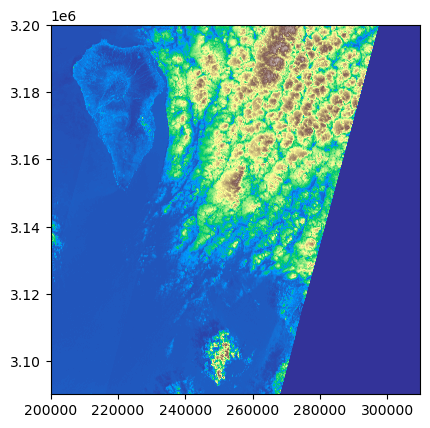

<AxesSubplot:>

In [5]:
data= rasterio.open(fp)
show((data,4), cmap='terrain')

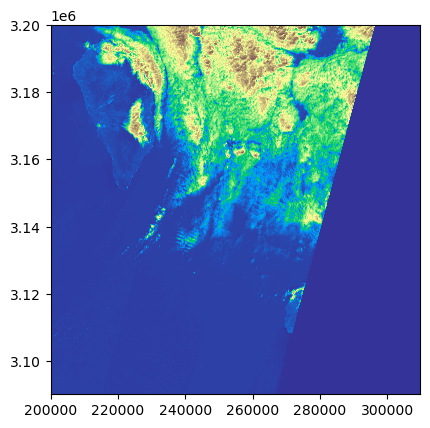

<AxesSubplot:>

In [6]:
data2 = rasterio.open(fp2)
show((data2,4), cmap='terrain')

In [5]:
#clipping raster with shapefile boundary la palma 
shapefp = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/La_palma_bounds.geojson'
out_clip = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped_10_09.jp2'
out_clip2 = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped_30_09.jp2'
data = rasterio.open(fp)
shape = gpd.GeoDataFrame.from_file(shapefp)

<AxesSubplot:>

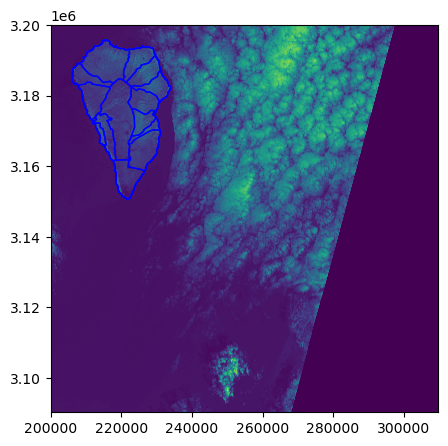

In [9]:
#plotting area for clipping
fig, ax = plt.subplots(figsize=(5, 15))
rasterio.plot.show(data, ax=ax)
shape.plot(ax=ax, facecolor='none', edgecolor='blue')

In [10]:
def getFeatures(gdf):
    """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
    import json
    return [json.loads(gdf.to_json())['features'][0]['geometry']]

coords = getFeatures(shape)
print (coords)

[{'type': 'MultiPolygon', 'coordinates': [[[[229698.9861224469, 3191456.3933205786], [229436.16169169568, 3191179.6696234974], [229265.13712628884, 3190988.815601483], [227665.34083187388, 3189193.9401506693], [225646.56110270892, 3188641.724091932], [225384.5299884504, 3187917.170088507], [224300.97014337068, 3187440.1748367185], [224165.5140759896, 3186900.929627728], [221352.1258128537, 3183695.493908999], [220382.01286477427, 3184462.6913212514], [221060.8443791147, 3185371.1669061715], [220596.01230933273, 3185600.6847268995], [220691.36234162725, 3187262.644698777], [221271.17701058672, 3188501.6538416636], [221101.281706433, 3188791.786801152], [221965.87262853805, 3189888.778973177], [221908.6865358504, 3190620.082350251], [222264.0936349472, 3190739.141286452], [221959.88931961107, 3191402.949920847], [222322.3690362408, 3191709.293300018], [222259.8639867084, 3192692.708479578], [222218.322689355, 3193112.411110904], [222683.4307418983, 3193101.265343975], [222684.16487516213

In [ ]:


out_img, out_transform = mask(dataset=data, shapes=coords, crop=True)

In [ ]:
with rasterio.open(fp) as src:
    # read the data as a numpy array
    data = src.read()

    # open the shapefile
    with fiona.open(shapefp, 'r') as shape:
        # get the first feature from the shapefile
        shapes = [feature["geometry"] for feature in shape]

        # clip the raster data using the shape geometry
        out_image, out_transform = mask(src, shapes, crop=True)
        out_meta = src.meta

# create a new raster file with the clipped data
with rasterio.open(out_clip, 'w', **out_meta) as dst:
    dst.write(out_image)

    

ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed
ERROR 1: Stream too short

ERROR 1: opj_get_decoded_tile() failed


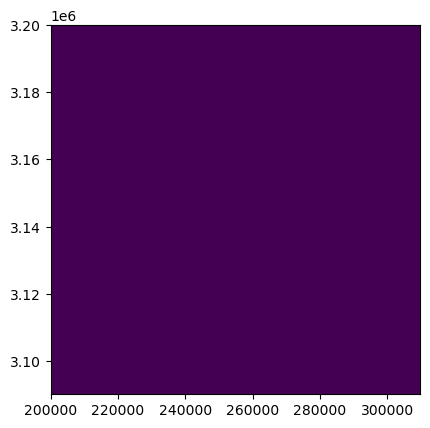

<AxesSubplot:>

In [8]:
clip =rasterio.open(out_clip)
show(clip)

In [ ]:
with rasterio.open(fp2) as src:
    # read the data as a numpy array
    data = src.read()

    # open the shapefile
    with fiona.open(shapefp, 'r') as shape:
        # get the first feature from the shapefile
         shapes = [feature["geometry"] for feature in shapefile]

        # clip the raster data using the shape geometry
        out_image, out_transform =  mask(src, shapes, crop=True)

# create a new raster file with the clipped data
with rasterio.open(out_clip2, 'w', **src.meta) as dst:
    dst.write(out_image)

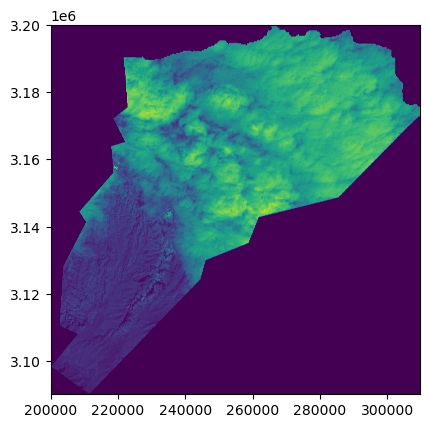

<AxesSubplot:>

In [7]:
clip2 =rasterio.open(out_clip2)
show(clip2)

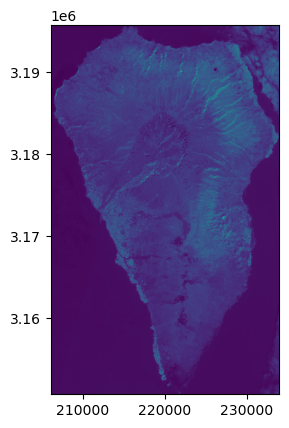

<AxesSubplot:>

In [5]:
#I also clipped using QGIS extent, the code I used, didn't clip by extent well so I used the QGIS clipped extents in part 2

qgis_clip_fp = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped_qgis_1009.tif'
clip_qgis = rasterio.open(qgis_clip_fp)
show(clip_qgis)


### 1.5 normalising of input normalising of input DN to a range

In [ ]:
#scaling to ensure all values in the raster file fall in the same range

In [ ]:
#showing the clipped files

In [ ]:
norm_data = NormalizeData(data)

In [ ]:
normalised_fp1 = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/normalised_10_09.tiff'
normalised_fp2 = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/normalised_30_09.tiff'

In [ ]:
# Open the JP2 file
with rasterio.open(out_clip) as src:
    # Read the data from the JP2 file
    data = src.read()
    # Normalize the DN values using numpy
    normalized_data = (data - data.min()) / (data.max() - data.min())
    # Get the metadata (e.g. CRS, transform, etc.) from the JP2 file
    meta = src.meta
    # Update the metadata to indicate that the file is now a GeoTIFF file
    meta.update(driver='GTiff')
    # Save the normalized data and metadata to a new GeoTIFF file
    with rasterio.open(normalised_fp1, 'w', **meta) as dst:
        dst.write(normalized_data)

In [ ]:
# Open the JP2 file
with rasterio.open(out_clip2) as src:
    # Read the data from the JP2 file
    data = src.read()
    # Normalize the DN values using numpy
    normalized_data = (data - data.min()) / (data.max() - data.min())
    # Get the metadata (e.g. CRS, transform, etc.) from the JP2 file
    meta = src.meta
    # Update the metadata to indicate that the file is now a GeoTIFF file
    meta.update(driver='GTiff')
    # Save the normalized data and metadata to a new GeoTIFF file
    with rasterio.open(normalised_fp2, 'w', **meta) as dst:
        dst.write(normalized_data)

## 2. Data science with GIS



### 2.1 population data and viz

In [10]:
gdf =gpd.read_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/La_palma_bounds.geojson')
gdf.head()
#data from: https://datos-lapalma.opendata.arcgis.com/datasets/poblaci%C3%B3n/explore?location=28.654644%2C-17.865820%2C10.86
pop_csv = gpd.read_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Poblaci%C3%B3n.csv')
pop_csv = pop_csv.astype({'poblacion':'int'})
total=pop_csv['poblacion'].sum() #check if it is population of la palma
print(total)
pop_bymunci = pop_csv.groupby('municipio').sum()
gdf['NAME_4']=gdf['NAME_4'].str.upper()
gdf = gdf.rename(columns={'NAME_4': 'municipio'})


83218


/var/folders/sf/7stnv88n2y36ft6t7494cr5w0000gn/T/ipykernel_3240/561085981.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  pop_bymunci = pop_csv.groupby('municipio').sum()


In [11]:
gdf

,NAME_0,NAME_1,NAME_2,NAME_3,municipio,geometry
0,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),BARLOVENTO,"MULTIPOLYGON (((229698.986 3191456.393, 229436..."
1,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),BREÑA ALTA,"MULTIPOLYGON (((229832.440 3173829.920, 229583..."
2,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),BREÑA BAJA,"MULTIPOLYGON (((230917.961 3170232.563, 230817..."
3,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),EL PASO,"MULTIPOLYGON (((222030.639 3166225.627, 222360..."
4,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),FUENCALIENTE DE LA PALMA,"MULTIPOLYGON (((221163.592 3150986.669, 221164..."
5,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),GARAFÍA,"MULTIPOLYGON (((217721.489 3183427.861, 216720..."
6,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),LOS LLANOS DE ARIDANE,"MULTIPOLYGON (((217609.171 3161486.051, 217604..."
7,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),PUNTAGORDA,"MULTIPOLYGON (((216691.050 3182385.710, 211636..."
8,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),PUNTALLANA,"MULTIPOLYGON (((231147.521 3187267.504, 231175..."
9,Spain,Islas Canarias,Santa Cruz de Tenerife,n.a. (144),SAN ANDRÉS Y SAUCES,"MULTIPOLYGON (((222782.733 3182451.101, 221352..."


In [20]:
pop_bymunci=pop_bymunci.reset_index()
merged_pop =pd.merge(pop_bymunci, gdf, on='municipio')
import matplotlib.colors as mcolors
merged_pop['log_poblacion'] = np.log(merged_pop['poblacion'])
merged_pop = gpd.GeoDataFrame(merged_pop)

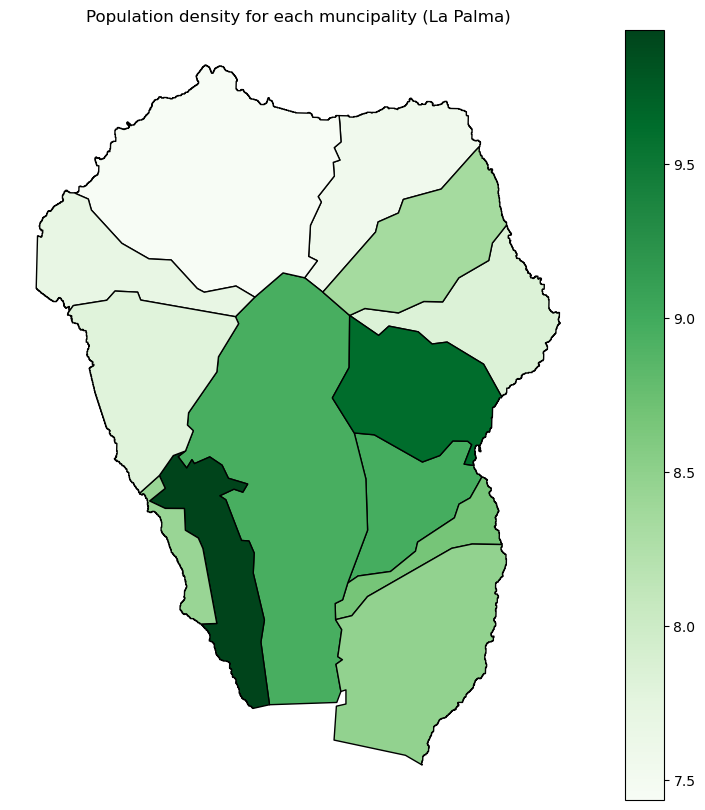

In [25]:
#choropleth map
fig, ax = plt.subplots(figsize=(10, 10))
norm = Normalize(vmin=merged_pop['log_poblacion'].min(), vmax=merged_pop['log_poblacion'].max())
merged_pop.plot(column='log_poblacion', ax=ax, cmap='Greens', legend=True, linewidth=1, edgecolor='black')
plt.axis('off')
plt.title('Population density for each muncipality (La Palma)')
plt.savefig('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/density_map.png', bbox_inches='tight')
plt.show()

### 2.2 show lava outflow of 30/09 

In [26]:
lava_fp = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/lava_outflow.tiff'

In [ ]:
#clipped area inQGIS 

In [29]:
from rasterio.features import geometry_mask

In [30]:

# Open the raster file using rasterio
with rasterio.open(lava_fp) as src:
    # Read the data and the transform for the raster
    data = src.read(1)
    transform = src.transform
    meta = src.meta
    print(meta)
    
    
    

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 879, 'height': 681, 'count': 4, 'crs': CRS.from_epsg(32628), 'transform': Affine(10.0, 0.0, 215060.0,
       0.0, -10.0, 3172720.0)}


In [ ]:
pixel_area

In [127]:
with rasterio.open(lava_fp) as src:
    meta = src.meta
    x_cell = meta['transform'].a
    y_cell = meta['transform'].e
    rasterWidth = meta['width'] * x_cell
    if y_cell < 0:
        rasterHeight = abs(meta['height'] * y_cell)
    else:
        rasterHeight = meta['height'] * y_cell
    rasterArea = rasterWidth * rasterHeight
    print(rasterArea)

59859900.0


In [ ]:
#area of raster file of lava_outflow



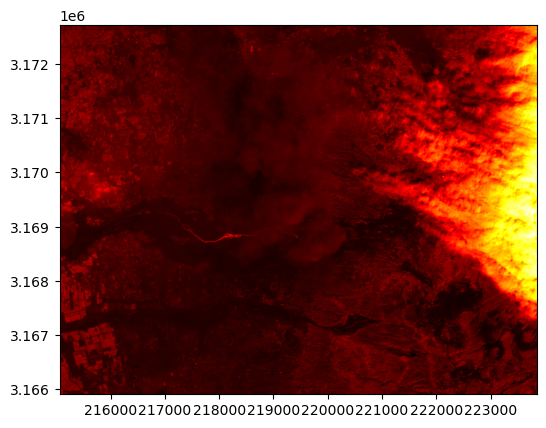

<AxesSubplot:>

In [32]:
lava_outflow = rasterio.open(lava_fp)
show(lava_outflow, cmap='hot')

In [122]:
with rasterio.open(lava_fp) as src:
    # Create a mask for the lava outflow area
    mask = mask(shapes=[(geometry.geometry, 1) for geometry in gpd.read_file(lava_fp)],
                        out_shape=src.shape,
                        transform=src.transform,
                        all_touched=True,
                        invert=False)
    # Count the number of non-zero pixels in the mask
    lava_pixels = mask.sum()
    # Calculate the area of the lava outflow in square meters
    lava_area = lava_pixels * (src.transform[0] * src.transform[4])
    print("Lava outflow area:", lava_area, "square meters")

DriverError: '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/lava_outflow.tiff' not recognized as a supported file format.

In [ ]:
from rasterio import mask


### 2.3 random forest model

In [ ]:
#open the shapefile of classification:

In [3]:
#read in tif file



raster_fp= '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped_qgis_1009.tif'
raster_ds = rasterio.open(raster_fp)

#read in shapefile of classification data and create a df of it 
gdf = gpd.read_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/true_data2.shp')
# get names of land cover classes/labels




using QGIS to train data points on raster file, by creating a new shapefile called truth data, I added points for each category on the raster file, 20 for each. I made sure the data was balanced so there was 20 in each category e.g. lc_type by checking its attribute file. There are many issues one can run into and as I was the only classifier, there is a high chance of misclassification. This can be avoided by having multiple classifiers to check the points have not been misclassified.  One can also use quality control process to review the labels and identify any errors e.g. classification, validiation steps. You can also use pre-trained object detection model that can help classification to reduce error.


In [4]:
class_names = gdf['lc_type'].unique() #classified usng QGIS from raster file of la palma
print(class_names)
class_ids = np.arange(class_names.size) +1
class_ids

['water' 'urban' 'veg' 'soil']


array([1, 2, 3, 4])

In [5]:
df = pd.DataFrame({'label': class_names, 'id': class_ids})
df.to_csv('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/class_lookup.csv')
gdf['id'] = gdf['lc_type'].map(dict(zip(class_names, class_ids)))

# split the truth data into training and test data sets and save each to a new shapefile
gdf_train = gdf.sample(frac=0.7)
gdf_test = gdf.drop(gdf_train.index)
print('gdf shape', gdf.shape, 'training shape', gdf_train.shape, 'test', gdf_test.shape)
gdf_train.to_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/train.shp')
gdf_test.to_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/test.shp')
gdf

gdf shape (79, 3) training shape (55, 3) test (24, 3)


,lc_type,geometry,id
0,water,POINT (210596.336 3173933.093),1
1,water,POINT (210802.803 3173563.172),1
2,water,POINT (211052.285 3173339.498),1
3,water,POINT (211310.370 3173012.591),1
4,water,POINT (211525.441 3172831.931),1
...,...,...,...
74,soil,POINT (216350.943 3175247.866),4
75,soil,POINT (216515.710 3174977.177),4
76,soil,POINT (216386.250 3175542.094),4
77,soil,POINT (216503.941 3175918.704),4


In [6]:
#1. read raster image and get band values
image_fn = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped_qgis_1009.tif'
with rasterio.open(image_fn) as src:
    bands = src.read()
    transform = src.transform
    crs = src.crs
    
    print(crs)
    

EPSG:32628


In [7]:
#2. training data 

training_shape =gpd.read_file( '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/train.shp')
# Extract the geometry information for each feature
geometry_train = training_shape['geometry']

# Extract the label information (in this case, the lctype column) for each feature
labels_train = training_shape['lc_type']

# Extract id for each feature
id_train = training_shape['id']

In [9]:
# 3. Extract corresponding pixel values from the raster image
pixel_values = []
for i in range(len(geometry_train)):
    if geometry_train[i].geom_type == 'Point':
        x, y = geometry_train.x[i], geometry_train.y[i]
        row, col = ~transform * (x, y)
        if (0 <= row < bands.shape[1]) and (0 <= col < bands.shape[2]):
            pixel_values.append(bands[:, int(row), int(col)])
        else:
            print(f'Coordinates of point {i} are out of bounds')
    else:
        mask = rasterio.features.geometry_mask(geometry_train[i], out_shape=bands.shape[1:], transform=transform)
        pixel_values.append(bands[:, mask].mean(axis=(1, 2)))

In [10]:
pixel_values

[array([3558,  385,  539,  364], dtype=uint16),
 array([709, 762, 722, 699], dtype=uint16),
 array([3786,  691,  847,  671], dtype=uint16),
 array([2197,  578,  759,  882], dtype=uint16),
 array([2426,  618,  798,  819], dtype=uint16),
 array([2745,  290,  434,  299], dtype=uint16),
 array([3326,  303,  451,  310], dtype=uint16),
 array([2177,  860, 1111, 1252], dtype=uint16),
 array([3359,  315,  493,  326], dtype=uint16),
 array([2433, 2541, 2386, 2348], dtype=uint16),
 array([773, 888, 820, 831], dtype=uint16),
 array([3430,  309,  524,  317], dtype=uint16),
 array([698, 738, 698, 651], dtype=uint16),
 array([3342,  514,  771,  667], dtype=uint16),
 array([792, 935, 856, 733], dtype=uint16),
 array([3212,  308,  500,  319], dtype=uint16),
 array([802, 912, 890, 892], dtype=uint16),
 array([2704,  319,  458,  284], dtype=uint16),
 array([2266,  903, 1149, 1357], dtype=uint16),
 array([2459,  832, 1031, 1148], dtype=uint16),
 array([2579,  288,  449,  292], dtype=uint16),
 array([2611

random forest models are often use for classification tasks such as in this case, it is appropiate to use for lots of features and can handle large datasets.It is less prone to overfitting than other decision tree-based models. It can also handle missing data and categorical variables. However, random forest models are also prone to overfitting if the number of trees is too high.

In [11]:
# 4. Train the Random Forest model
clf = RandomForestClassifier()
clf.fit(pixel_values, labels_train)

RandomForestClassifier()

In [12]:
# 5. Read in the testing shapefile and extract geometry and labels
shapefile_test = gpd.read_file('/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/test.shp')
geometry_test = shapefile_test['geometry']
labels_test = shapefile_test['lc_type']


In [13]:

# 6. Extract corresponding pixel values from the raster image for the testing data    
pixel_values_test = []
for i in range(len(geometry_test)):
    if geometry_test[i].geom_type == 'Point':
        x, y = geometry_test.x[i], geometry_test.y[i]
        row, col = ~transform * (x, y)
        if (0 <= row < bands.shape[1]) and (0 <= col < bands.shape[2]):
            pixel_values_test.append(bands[:, int(row), int(col)])
        else:
            print(f'Coordinates of point {i} are out of bounds')
    else:
        mask = rasterio.features.geometry_mask(geometry_test[i], out_shape=bands.shape[1:], transform=transform)
        pixel_values_test.append(bands[:, mask].mean(axis=(1, 2)))



In [14]:
pixel_values_test

[array([1528,  511,  698,  811], dtype=uint16),
 array([5090,  819, 1139,  867], dtype=uint16),
 array([2575,  836, 1051, 1557], dtype=uint16),
 array([4234,  533,  810,  680], dtype=uint16),
 array([2292, 2229, 2197, 2206], dtype=uint16),
 array([2850,  255,  384,  258], dtype=uint16),
 array([2616,  291,  486,  332], dtype=uint16),
 array([3577,  300,  512,  320], dtype=uint16),
 array([3347,  593,  740,  571], dtype=uint16),
 array([2505,  494,  678,  531], dtype=uint16),
 array([1651,  420,  572,  591], dtype=uint16),
 array([2202,  487,  750,  659], dtype=uint16),
 array([2629,  563,  777,  831], dtype=uint16),
 array([668, 774, 708, 673], dtype=uint16),
 array([743, 857, 819, 804], dtype=uint16),
 array([2995, 3039, 2920, 2910], dtype=uint16),
 array([2261,  254,  388,  299], dtype=uint16),
 array([4690,  821, 1134,  832], dtype=uint16),
 array([2795,  281,  395,  285], dtype=uint16),
 array([2746,  305,  413,  290], dtype=uint16),
 array([2022,  309,  501,  372], dtype=uint16),


In [15]:
# 7. Predict labels for testing data
predictions = clf.predict(pixel_values_test)

# 8. Evaluate model performance
accuracy = accuracy_score(labels_test, predictions)
print(f'Accuracy of the model: {accuracy}')

import seaborn
seaborn.heatmap(CM)
plt.show()

Accuracy of the model: 0.4583333333333333


Accuracy score 0.375 means that only 37.5% of the test set is correctly classified by the model. This suggests that model is not properly capturing the features. This is probably due to the low quality training data and it needs to be reviewed to ensure the feautures are correctly labels. 

In [17]:
from sklearn.metrics import confusion_matrix

In [21]:
predictions

array(['veg', 'urban', 'urban', 'urban', 'veg', 'urban', 'soil', 'soil',
       'urban', 'urban', 'veg', 'veg', 'urban', 'veg', 'veg', 'veg',
       'soil', 'urban', 'soil', 'soil', 'soil', 'urban', 'urban', 'urban'],
      dtype=object)

In [22]:
labels_test

0     water
1     water
2     water
3     water
4     water
5     urban
6     urban
7     urban
8     urban
9     urban
10    urban
11      veg
12      veg
13      veg
14      veg
15      veg
16     soil
17     soil
18     soil
19     soil
20     soil
21     soil
22     soil
23     soil
Name: lc_type, dtype: object

[[4 4 0 0]
 [2 3 1 0]
 [0 1 4 0]
 [0 3 2 0]]


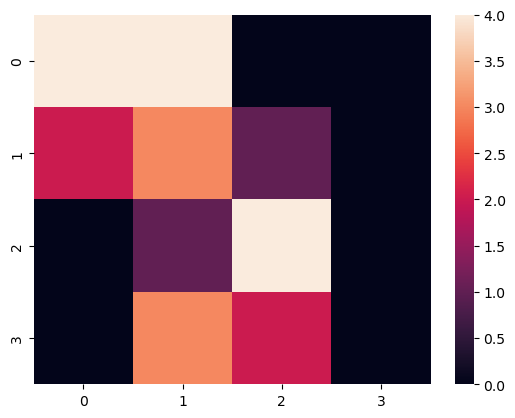

In [19]:
conf_mat = confusion_matrix(labels_test, predictions)
print(conf_mat)
import seaborn
seaborn.heatmap(conf_mat)
plt.show()
#water,urban,veg,soil

The confusion matrix shows each row for each feature type. The first row looks at the water class, this row indicates that 1 out of 7 water samples were classified as "urban", the second column indicates that 1 out of 7 water samples were classified as "vegetation".
Next, at the urban class, it shows indicates that 1 out of 2 urban samples were classified as "water", the second column indicates that 1 out of 2 urban samples were classified as "urban". The third row of the matrix corresponds to the "vegetation" class. The first column of this row indicates that 0 out of 0 vegetation samples were classified as "water", the second column indicates that 0 out of 0 vegetation samples were classified as "urban". Lastly, the matrix corresponds to the soil feature, it shows 0 out of 1 sand/soil/rock samples were classified as "water", the second column indicates that 1 out of 1 soil samples were classified as "urban", and so on.


To calc urban loss, compare pixels that are classified as urban between 10/09 in the previous model and using the training data of 10/09 to test on 30/09 raster file.

In [29]:
image_fn = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/clipped3009_qgis.tiff'
with rasterio.open(image_fn) as src:
    bands2 = src.read()
    transform = src.transform
    crs = src.crs
    
    print(crs)

EPSG:32628


In [30]:
#to predict on 30/09 image, second one
# 6. Extract corresponding pixel values from the raster image for the testing data    
pixel_values_test2 = []
for i in range(len(geometry_test)):
    if geometry_test[i].geom_type == 'Point':
        x, y = geometry_test.x[i], geometry_test.y[i]
        row, col = ~transform * (x, y)
        if (0 <= row < bands2.shape[1]) and (0 <= col < bands2.shape[2]):
            pixel_values_test2.append(bands[:, int(row), int(col)])
        else:
            print(f'Coordinates of point {i} are out of bounds')
    else:
        mask = rasterio.features.geometry_mask(geometry_test[i], out_shape=bands2.shape[1:], transform=transform)
        pixel_values_test2.append(bands2[:, mask].mean(axis=(1, 2)))

In [31]:
pixel_values_test2

[array([2197,  578,  759,  882], dtype=uint16),
 array([792, 935, 856, 733], dtype=uint16),
 array([1617, 1747, 1603, 1529], dtype=uint16),
 array([2292, 2229, 2197, 2206], dtype=uint16),
 array([1504, 1577, 1524, 1452], dtype=uint16),
 array([802, 912, 890, 892], dtype=uint16),
 array([2704,  319,  458,  284], dtype=uint16),
 array([2505,  494,  678,  531], dtype=uint16),
 array([2426,  618,  798,  819], dtype=uint16),
 array([2266,  903, 1149, 1357], dtype=uint16),
 array([2629,  563,  777,  831], dtype=uint16),
 array([1691,  388,  586,  530], dtype=uint16),
 array([2611, 1071, 1301, 1410], dtype=uint16),
 array([2433, 2541, 2386, 2348], dtype=uint16),
 array([2995, 3039, 2920, 2910], dtype=uint16),
 array([2751, 2871, 2785, 2612], dtype=uint16),
 array([3212,  308,  500,  319], dtype=uint16),
 array([2795,  281,  395,  285], dtype=uint16),
 array([2746,  305,  413,  290], dtype=uint16),
 array([2745,  290,  434,  299], dtype=uint16),
 array([3492,  273,  480,  283], dtype=uint16),


In [ ]:
# 7. Predict labels for testing data
predictions2 = clf.predict(pixel_values_test2)

# 8. Evaluate model performance
accuracy = accuracy_score(labels_test, predictions2)
print(f'Accuracy of the model: {accuracy}')

#Accuracy of the model: 0.20833333333333334

[[0 4 0 4]
 [0 0 0 5]
 [0 0 0 6]
 [0 0 0 5]]

In [32]:
# 7. Predict labels for testing data
predictions2 = clf.predict(pixel_values_test2)

# 8. Evaluate model performance
accuracy = accuracy_score(labels_test, predictions2)
print(f'Accuracy of the model: {accuracy}')


Accuracy of the model: 0.3333333333333333


In [33]:
conf_mat = confusion_matrix(labels_test, predictions2)
print(conf_mat)

[[3 5 0 0]
 [1 1 0 2]
 [0 1 2 3]
 [0 0 4 2]]


In [ ]:
#difference between pixels before in the 10/09 and 30/09 of urban loss

## 3. Querying vector data and perform analysis

In [ ]:
#load packages 


In [72]:
import overpy
import requests
import json
from geopy.geocoders import Nominatim
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import osmnx as ox
import numpy as np
from scipy.interpolate import griddata
import networkx as nx

import osmnx as ox
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import tempfile
import geopandas as gpd
import networkx as nx
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextily as ctx

### 3.1 query health centers in la palma

In [73]:
#to ensure its in la palma, spain
city_name = "la palma"

# Geocoding request via Nominatim
geolocator = Nominatim(user_agent="city_compare")
geo_results = geolocator.geocode(city_name, exactly_one=False, limit=3)

# Searching for relation in result set
for r in geo_results:
    print(r.address, r.raw.get("osm_type"))
    if r.raw.get("osm_type") == "relation":
        city = r
        break

# Calculating area id
area_id = int(city.raw.get("osm_id")) + 3600000000
#area_id to ensure it is La Palma in Spain
print(area_id)

La Palma, Santa Cruz de Tenerife, Canarias, España relation
3611775386


In [76]:
#check thgis again
api = overpy.Overpass()
result1 = api.query("""
    area(%s)->.searchArea;
    (
    node["amenity"="hospital"](area.searchArea);
     way["amenity"="hospital"](area.searchArea);
     rel["amenity"="hospital"](area.searchArea);
     node["amenity"="pharmacy"](area.searchArea);
     way["amenity"="pharmacy"](area.searchArea);
     rel["amenity"="pharmacy"](area.searchArea);
     node["amenity"="clinic"](area.searchArea);
     way["amenity"="clinic"](area.searchArea);
     rel["amenity"="clinic"](area.searchArea);
     node["amenity"="dentist"](area.searchArea);
     way["amenity"="dentist"](area.searchArea);
     rel["amenity"="dentist"](area.searchArea);
     node["amenity"="veterinary"](area.searchArea);
     way["amenity"="veterinary"](area.searchArea);
     rel["amenity"="veterinary"](area.searchArea););
out body;
    """ % area_id)

    

# print the number of healthcare facilities found
print("Number of healthcare facilities:", len(result1.nodes))

# print the names, addresses, and coordinates of the healthcare facilities
for node in result1.nodes:
    print("Name:", node.tags.get("name", "n/a"))
    print("Address:", node.tags.get("address", "n/a"))
    print("Coordinates:", node.lat, node.lon)
    print("---")

Number of healthcare facilities: 39
Name: Farmacia
Address: n/a
Coordinates: 28.6519106 -17.9465997
---
Name: Centro de Salud Puntagorda
Address: n/a
Coordinates: 28.7708734 -17.9792926
---
Name: Consultorio Periférico de Fuencaliente
Address: n/a
Coordinates: 28.4930226 -17.8456925
---
Name: Centro de Salud Puerto de Tazacorte
Address: n/a
Coordinates: 28.6516112 -17.9452524
---
Name: Farmacia
Address: n/a
Coordinates: 28.6814462 -17.7666300
---
Name: Farmacia del Puente del Doctor Argany
Address: n/a
Coordinates: 28.6836407 -17.7643824
---
Name: Capote Cabrera
Address: n/a
Coordinates: 28.6867622 -17.7613755
---
Name: Farmacia
Address: n/a
Coordinates: 28.6680388 -17.7861251
---
Name: n/a
Address: n/a
Coordinates: 28.6462936 -17.7671803
---
Name: Farmacia
Address: n/a
Coordinates: 28.8033649 -17.7734108
---
Name: n/a
Address: n/a
Coordinates: 28.6417211 -17.9342239
---
Name: n/a
Address: n/a
Coordinates: 28.6507238 -17.8805771
---
Name: n/a
Address: n/a
Coordinates: 28.7656181 -17.97

In [77]:
#get the lat and lon of health centres as gpd dataframe

for node in result1.nodes:
     print("", node.lat, node.lon)
coords = []

# Iterate through the nodes and extract the coordinates
for node in result1.nodes:
    coord = (node.lat, node.lon)
    coords.append(coord)

# Create a DataFrame from the coordinates list
health_coords = pd.DataFrame(coords, columns=['latitude', 'longitude'])

# Print the DataFrame
print(health_coords)

gdf_health_facilities = gpd.GeoDataFrame(health_coords, geometry=gpd.points_from_xy(health_coords.longitude, health_coords.latitude))
gdf_health_facilities

 28.6519106 -17.9465997
 28.7708734 -17.9792926
 28.4930226 -17.8456925
 28.6516112 -17.9452524
 28.6814462 -17.7666300
 28.6836407 -17.7643824
 28.6867622 -17.7613755
 28.6680388 -17.7861251
 28.6462936 -17.7671803
 28.8033649 -17.7734108
 28.6417211 -17.9342239
 28.6507238 -17.8805771
 28.7656181 -17.9787626
 28.7391325 -17.7448724
 28.5869687 -17.9095252
 28.6585916 -17.9117805
 28.6827043 -17.7651521
 28.7109615 -17.9568129
 28.7141962 -17.9569738
 28.7104235 -17.9556495
 28.6575542 -17.9170070
 28.6463251 -17.7595185
 28.6577733 -17.9123019
 28.7666429 -17.9795101
 28.6837054 -17.7652188
 28.6564099 -17.9092207
 28.8286858 -17.8034568
 28.6526865 -17.8813314
 28.6580995 -17.9174297
 28.6580313 -17.9153482
 28.6862219 -17.7611927
 28.6877901 -17.7597629
 28.6816500 -17.7653715
 28.4940136 -17.8442242
 28.6213025 -17.7525348
 28.6063728 -17.7801268
 28.8050178 -17.7746174
 28.8277038 -17.9479343
 28.6726877 -17.7903818
      latitude    longitude
0   28.6519106  -17.9465997
1   28.7

,latitude,longitude,geometry
0,28.6519106,-17.9465997,POINT (-17.94660 28.65191)
1,28.7708734,-17.9792926,POINT (-17.97929 28.77087)
2,28.4930226,-17.8456925,POINT (-17.84569 28.49302)
3,28.6516112,-17.9452524,POINT (-17.94525 28.65161)
4,28.6814462,-17.7666300,POINT (-17.76663 28.68145)
5,28.6836407,-17.7643824,POINT (-17.76438 28.68364)
6,28.6867622,-17.7613755,POINT (-17.76138 28.68676)
7,28.6680388,-17.7861251,POINT (-17.78613 28.66804)
8,28.6462936,-17.7671803,POINT (-17.76718 28.64629)
9,28.8033649,-17.7734108,POINT (-17.77341 28.80336)


### 3.2 road networks using osmnx

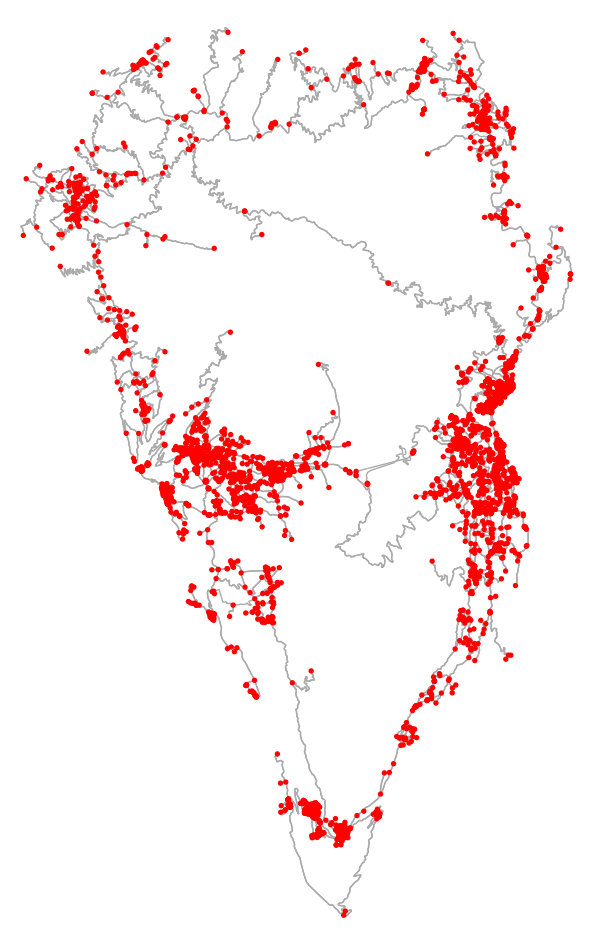

epsg:4326


In [79]:
G= ox.graph_from_place('La Palma Spain', network_type='drive')
ox.plot_graph(G, bgcolor='w', node_color='r', edge_color="#aaa", figsize=(12,12))
print(G.graph['crs'])

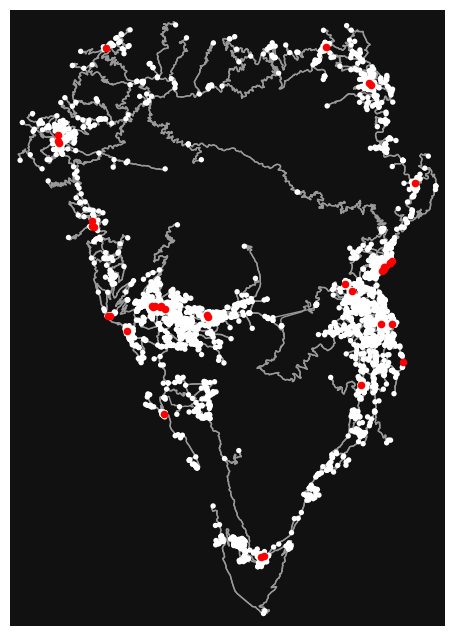

In [80]:
#convert road network query to a gdf

G_gdf = ox.graph_to_gdfs(G, edges=True, nodes=False)
fig, ax = ox.plot_graph(G, show=False)

# Plot the health facilities on top of the road network
gdf_health_facilities.plot(ax=ax, color='red', markersize=20)

# Show the plot
plt.show()

In [ ]:
print("node count:", len(G.nodes()))
print("edge count:", len(G.edges()))

### 3.3 analysing streetnetworks

In [81]:
origins_X = gdf_health_facilities['longitude'].tolist()
origins_X = [float(x) for x in origins_X]
origins_Y = gdf_health_facilities['latitude'].tolist()
origins_Y = [float(x) for x in origins_Y]
nodes, dists = ox.distance.nearest_nodes(G, origins_X, origins_Y, return_dist=True)

In [82]:
nodes, dists = ox.distance.nearest_nodes(G, origins_X, origins_Y, return_dist=True)

In [84]:
nodes

[935605820,
 863478298,
 9140111086,
 702973322,
 585025872,
 305229561,
 1199338730,
 1197717827,
 304300163,
 1972876931,
 482857072,
 10096391316,
 334812959,
 305275745,
 398953493,
 1086651667,
 305229565,
 304122749,
 418791798,
 457357825,
 706736666,
 460947161,
 9695712719,
 911881180,
 305229562,
 307057417,
 480074858,
 533799646,
 706736672,
 6521811480,
 305229421,
 370120731,
 305229383,
 290691492,
 401297346,
 7025736005,
 292873043,
 533702005,
 7424868423]

In [83]:
G_gdf = ox.graph_to_gdfs(G, edges=True, nodes=False)

In [85]:
# find the centermost node and then project the graph to UTM
gdf_nodes = ox.graph_to_gdfs(G, edges=False)
x, y = gdf_nodes["geometry"].unary_union.centroid.xy
center_node = ox.distance.nearest_nodes(G, x[0], y[0])
G = ox.project_graph(G)

In [87]:
center_node

317986740

In [88]:
center_node =ox.distance.nearest_nodes(G, origins_X[0], origins_Y[0])
trip_times = [10,20,30,40,50,60,70,80,100]

# get one color for each isochrone
iso_colors = ox.plot.get_colors(n=len(trip_times), cmap="plasma", start=0, return_hex=True)

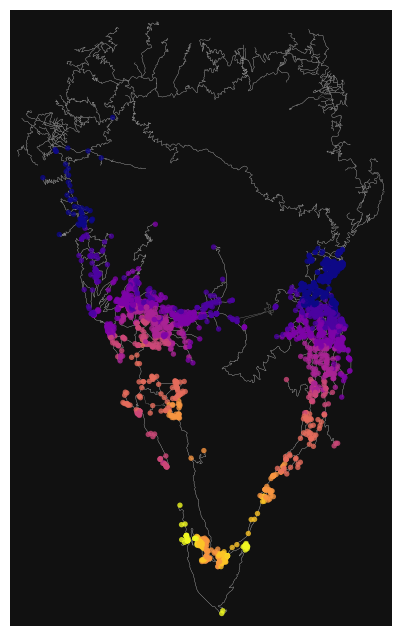

In [91]:
# color the nodes according to isochrone then plot the street network
node_colors = {}
for trip_time, color in zip(sorted(trip_times, reverse=True), iso_colors):
    subgraph = nx.ego_graph(G, center_node, radius=trip_time, distance="time")
    for node in subgraph.nodes():
        node_colors[node] = color
nc = [node_colors[node] if node in node_colors else "none" for node in G.nodes()]
ns = [15 if node in node_colors else 0 for node in G.nodes()]
fig, ax = ox.plot_graph(
    G,
    node_color=nc,
    node_size=ns,
    node_alpha=0.8,
    edge_linewidth=0.2,
    edge_color="#999999",
)

In [92]:
matrix = np.zeros((len(nodes), len(nodes)))

for i in range(len(nodes)):
    for j in range(i, len(nodes)):
        if i == j:
            matrix[i][j] = 0
        else:
            # calculate the shortest path by drive time
            distance = nx.single_source_dijkstra_path_length(G, nodes[i], weight='travel_time')
            matrix[i][j] = distance.get(nodes[j], float('inf'))
            matrix[j][i] = distance.get(nodes[j], float('inf'))

In [93]:
df=pd.DataFrame(matrix, index=nodes, columns=nodes)


In [94]:
df

,935605820,863478298,9140111086,702973322,585025872,305229561,1199338730,1197717827,304300163,1972876931,...,6521811480,305229421,370120731,305229383,290691492,401297346,7025736005,292873043,533702005,7424868423
935605820,0.0,59.0,58.0,6.0,81.0,75.0,79.0,81.0,89.0,91.0,...,38.0,74.0,70.0,77.0,57.0,97.0,93.0,89.0,53.0,82.0
863478298,59.0,0.0,90.0,54.0,46.0,40.0,44.0,46.0,54.0,56.0,...,70.0,39.0,35.0,42.0,89.0,62.0,74.0,54.0,18.0,48.0
9140111086,58.0,90.0,0.0,57.0,97.0,87.0,93.0,84.0,68.0,128.0,...,48.0,89.0,93.0,85.0,4.0,62.0,46.0,126.0,90.0,78.0
702973322,6.0,54.0,57.0,0.0,80.0,74.0,78.0,80.0,88.0,90.0,...,37.0,73.0,69.0,76.0,56.0,96.0,92.0,88.0,52.0,81.0
585025872,81.0,46.0,97.0,80.0,0.0,5.0,13.0,42.0,33.0,68.0,...,90.0,9.0,13.0,7.0,94.0,41.0,53.0,66.0,34.0,45.0
305229561,75.0,40.0,87.0,74.0,5.0,0.0,8.0,37.0,28.0,63.0,...,85.0,4.0,8.0,2.0,89.0,36.0,48.0,61.0,29.0,40.0
1199338730,79.0,44.0,93.0,78.0,13.0,8.0,0.0,39.0,32.0,62.0,...,84.0,2.0,4.0,6.0,93.0,40.0,52.0,60.0,28.0,41.0
1197717827,81.0,46.0,84.0,80.0,42.0,37.0,39.0,0.0,31.0,74.0,...,73.0,37.0,39.0,35.0,81.0,43.0,40.0,72.0,40.0,17.0
304300163,89.0,54.0,68.0,88.0,33.0,28.0,32.0,31.0,0.0,83.0,...,84.0,29.0,33.0,25.0,68.0,19.0,27.0,81.0,49.0,32.0
1972876931,91.0,56.0,128.0,90.0,68.0,63.0,62.0,74.0,83.0,0.0,...,102.0,63.0,59.0,66.0,121.0,86.0,98.0,4.0,46.0,72.0


### 3.4 lava outflow to see if any health facilities are affected

In [95]:
gdf_health_facilities

,latitude,longitude,geometry
0,28.6519106,-17.9465997,POINT (-17.94660 28.65191)
1,28.7708734,-17.9792926,POINT (-17.97929 28.77087)
2,28.4930226,-17.8456925,POINT (-17.84569 28.49302)
3,28.6516112,-17.9452524,POINT (-17.94525 28.65161)
4,28.6814462,-17.7666300,POINT (-17.76663 28.68145)
5,28.6836407,-17.7643824,POINT (-17.76438 28.68364)
6,28.6867622,-17.7613755,POINT (-17.76138 28.68676)
7,28.6680388,-17.7861251,POINT (-17.78613 28.66804)
8,28.6462936,-17.7671803,POINT (-17.76718 28.64629)
9,28.8033649,-17.7734108,POINT (-17.77341 28.80336)


In [96]:
#open 30.10 raster file
lava_fp = '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/lava_outflow.tiff'

In [97]:
out_fp= '/Users/foroghakbari/GitHub/SDGAI_GIS/Datasets_Fellowship/Output/vector.geojson'

In [113]:
from rasterio import features
import shapely.geometry

In [114]:
with rasterio.open(lava_fp) as src:
    data = src.read(1)
    transform = src.transform
    meta = src.meta
    vector_data =features.shapes(data, mask=None, transform=src.transform)
    vector_data_list = list(vector_data)
    gdf = gpd.GeoDataFrame()
    gdf['geometry'] = [shapely.geometry.shape(geom) for geom, val in vector_data_list]
    gdf['value'] = [val for geom, val in vector_data_list]
    gdf.set_geometry('geometry', inplace=True)
    gdf.crs = src.crs
    gdf.to_file(out_fp, driver='GeoJSON')

    #had to change def function

In [115]:
gdf

,geometry,value
0,"POLYGON ((215060.000 3172720.000, 215060.000 3...",1867.0
1,"POLYGON ((215070.000 3172720.000, 215070.000 3...",1734.0
2,"POLYGON ((215080.000 3172720.000, 215080.000 3...",1697.0
3,"POLYGON ((215090.000 3172720.000, 215090.000 3...",1547.0
4,"POLYGON ((215100.000 3172720.000, 215100.000 3...",1490.0
...,...,...
590745,"POLYGON ((223800.000 3165920.000, 223800.000 3...",1832.0
590746,"POLYGON ((223810.000 3165920.000, 223810.000 3...",2082.0
590747,"POLYGON ((223820.000 3165920.000, 223820.000 3...",1998.0
590748,"POLYGON ((223830.000 3165920.000, 223830.000 3...",1912.0


In [116]:
gdf_lava = gpd.read_file(out_fp, driver='GeoJSON')


In [117]:
gdf_lava

,value,geometry
0,1867.0,"POLYGON ((215060.000 3172720.000, 215060.000 3..."
1,1734.0,"POLYGON ((215070.000 3172720.000, 215070.000 3..."
2,1697.0,"POLYGON ((215080.000 3172720.000, 215080.000 3..."
3,1547.0,"POLYGON ((215090.000 3172720.000, 215090.000 3..."
4,1490.0,"POLYGON ((215100.000 3172720.000, 215100.000 3..."
...,...,...
590745,1832.0,"POLYGON ((223800.000 3165920.000, 223800.000 3..."
590746,2082.0,"POLYGON ((223810.000 3165920.000, 223810.000 3..."
590747,1998.0,"POLYGON ((223820.000 3165920.000, 223820.000 3..."
590748,1912.0,"POLYGON ((223830.000 3165920.000, 223830.000 3..."


In [118]:
result = gpd.sjoin(gdf_health_facilities, gdf_lava, op='within')

# Check if any rows were returned, indicating an overlap
if not result.empty:
    print("Some health facilities are affected by the lava outflow.")
else:
    print("No health facilities are affected by the lava outflow.")

/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3377: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):
/var/folders/sf/7stnv88n2y36ft6t7494cr5w0000gn/T/ipykernel_7903/654546081.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:32628

  result = gpd.sjoin(gdf_health_facilities, gdf_lava, op='within')


No health facilities are affected by the lava outflow.
